Import important packages

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.metrics import mean_absolute_error as mae

from statsforecast.models import AutoARIMA, AutoETS
from statsforecast import StatsForecast
import matplotlib.pyplot as plt
from prophet import Prophet


rain_data = pd.read_csv('C:/Users/LENOVO/Documents/python_data_analytics_course/Pod 2 Project/weda.io/utils/data/rainfall_2000_2026.csv')

c:\Users\LENOVO\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


DATA CLEANING, PREPROCESSING AND FEATURE ENGINEERING

In [ ]:
rain_data.drop('extreme_rain', axis = 1, inplace= True)

#Convert data to datetime object and create new columns for month and year

rain_data['date'] = pd.to_datetime(rain_data['date'])
rain_data['year'] = rain_data['date'].dt.year

rain_data.head()


,date,tp,year
0,2000-01-01,0.098983,2000
1,2000-02-01,0.022955,2000
2,2000-03-01,4.152157,2000
3,2000-04-01,20.045437,2000
4,2000-05-01,86.753920,2000


DATA SPLITTING

In [3]:
rain_data['unique_id'] = 'rain'
rain_train = rain_data[rain_data['year'] <= 2023].copy()
rain_train.drop(columns=['year'], axis = 1, inplace= True)
rain_test = rain_data[rain_data['year'] > 2023].copy()
rain_test.drop(columns=['year'], axis = 1, inplace= True)

rain_train

,date,tp,unique_id
0,2000-01-01,0.098983,rain
1,2000-02-01,0.022955,rain
2,2000-03-01,4.152157,rain
3,2000-04-01,20.045437,rain
4,2000-05-01,86.753920,rain
...,...,...,...
283,2023-08-01,214.687110,rain
284,2023-09-01,113.393456,rain
285,2023-10-01,71.243700,rain
286,2023-11-01,17.048330,rain


COLUMN REFORMATTING TO STATSFORECAST FORMAT

In [4]:
rain_train = rain_train.rename(columns={
    'date':'ds',
    'tp':'y'
})

rain_test = rain_test.rename(columns={
    'date':'ds',
    'tp':'y'
})

INSPECT DATA

In [5]:
rain_train

,ds,y,unique_id
0,2000-01-01,0.098983,rain
1,2000-02-01,0.022955,rain
2,2000-03-01,4.152157,rain
3,2000-04-01,20.045437,rain
4,2000-05-01,86.753920,rain
...,...,...,...
283,2023-08-01,214.687110,rain
284,2023-09-01,113.393456,rain
285,2023-10-01,71.243700,rain
286,2023-11-01,17.048330,rain


In [18]:
rain_test

,ds,y,unique_id
288,2024-01-01,0.010531,rain
289,2024-02-01,0.590856,rain
290,2024-03-01,3.257770,rain
291,2024-04-01,19.234500,rain
292,2024-05-01,15.561078,rain
293,2024-06-01,47.245220,rain
294,2024-07-01,179.374370,rain
295,2024-08-01,149.784680,rain
296,2024-09-01,219.465500,rain
297,2024-10-01,118.260440,rain


In [6]:
freq = pd.infer_freq(rain_train.ds)

freq

'MS'

TRAINING
- SARIMA
- SARIMA (WITH LOGGED RAINFALL VALUES)
- AUTOETS
- AUTOETS (WITH LOGGED RAINFALL VALUES)
- PROPHET
- PROPHET (WITH LOGGED RAINFALL VALUES)

SARIMA AND ETS

In [7]:
sarima = AutoARIMA(season_length=12, alias = 'SARIMA')
ets = AutoETS(season_length=12, alias = 'ETS')
sf = StatsForecast(models = [sarima, ets], freq = 'MS')
sf.fit(rain_train)
pred = sf.predict(h = 24)

pred.head()

,unique_id,ds,SARIMA,ETS
0,rain,2024-01-01,3.274950,-10.251114
1,rain,2024-02-01,4.193778,-8.188589
2,rain,2024-03-01,10.294540,-2.263906
3,rain,2024-04-01,31.208481,24.215477
4,rain,2024-05-01,76.957625,69.915552


In [8]:
rain_test.reset_index(inplace = True)

In [ ]:
df = pred
df['Actual'] = rain_test.y

df

,unique_id,ds,SARIMA,ETS,Actual
0,rain,2024-01-01,3.274950,-10.251114,0.010531
1,rain,2024-02-01,4.193778,-8.188589,0.590856
2,rain,2024-03-01,10.294540,-2.263906,3.257770
3,rain,2024-04-01,31.208481,24.215477,19.234500
4,rain,2024-05-01,76.957625,69.915552,15.561078
5,rain,2024-06-01,140.047808,129.753604,47.245220
6,rain,2024-07-01,176.236435,173.869861,179.374370
7,rain,2024-08-01,241.335844,233.789844,149.784680
8,rain,2024-09-01,239.457048,215.486148,219.465500
9,rain,2024-10-01,82.732756,67.955392,118.260440


In [10]:
sarima_mae = mae(df['Actual'], df['SARIMA'])
ets_mae = mae(df['Actual'], df['ETS'])
sarima_mae, ets_mae

(24.1372767218335, 24.58402142522591)

SARIMA AND ETS WITH LOGGED RAINFALL VALUES

LOGGING THE RAINFALL VALUES

In [17]:
logged_rain_train = rain_train[['ds', 'y', 'unique_id']].copy()

from sklearn.preprocessing import StandardScaler

scaler = MinMaxScaler()
scaler.fit(logged_rain_train[['y']])
logged_rain_train['y']= scaler.transform(logged_rain_train[['y']])


logged_rain_train

,ds,y,unique_id
0,2000-01-01,0.000264,rain
1,2000-02-01,0.000061,rain
2,2000-03-01,0.011092,rain
3,2000-04-01,0.053550,rain
4,2000-05-01,0.231757,rain
...,...,...,...
283,2023-08-01,0.573522,rain
284,2023-09-01,0.302923,rain
285,2023-10-01,0.190323,rain
286,2023-11-01,0.045543,rain


In [18]:
sarima_log = AutoARIMA(season_length=12, alias= 'SARIMA_log')
ets_log = AutoETS(season_length = 12, alias = 'ETS_log')


sf = StatsForecast(models = [sarima_log, ets_log], freq = freq)
sf.fit(logged_rain_train)
logged_pred = sf.predict(h = 24)



In [20]:
logged_pred

,unique_id,ds,SARIMA_log,ETS_log
0,rain,2024-01-01,0.008749,-0.027385
1,rain,2024-02-01,0.011203,-0.021875
2,rain,2024-03-01,0.027501,-0.006048
3,rain,2024-04-01,0.083371,0.064690
4,rain,2024-05-01,0.205587,0.186774
5,rain,2024-06-01,0.374128,0.346628
6,rain,2024-07-01,0.470803,0.464481
7,rain,2024-08-01,0.644712,0.624553
8,rain,2024-09-01,0.639693,0.575656
9,rain,2024-10-01,0.221015,0.181538


In [19]:
inv_pred = logged_pred[['ds']].copy()

inv_pred['SARIMA_log'] = scaler.inverse_transform(
    logged_pred[['SARIMA_log']]
).ravel()

inv_pred['ETS_log'] = scaler.inverse_transform(
    logged_pred[['ETS_log']]
).ravel()
 
inv_pred

,ds,SARIMA_log,ETS_log
0,2024-01-01,3.274951,-10.251114
1,2024-02-01,4.193778,-8.188589
2,2024-03-01,10.294540,-2.263906
3,2024-04-01,31.208481,24.215477
4,2024-05-01,76.957625,69.915552
5,2024-06-01,140.047808,129.753604
6,2024-07-01,176.236435,173.869861
7,2024-08-01,241.335843,233.789844
8,2024-09-01,239.457046,215.486148
9,2024-10-01,82.732755,67.955392


In [80]:
df['SARIMA_log'] = inv_pred[['SARIMA_log']].copy()
df['ETS_log'] = inv_pred[['ETS_log']].copy()
df

,unique_id,ds,SARIMA,ETS,Actual,SARIMA_log,ETS_log
0,rain,2024-01-01,3.274950,-10.251114,0.010531,3.274951,-9.756627
1,rain,2024-02-01,4.193778,-8.188589,0.590856,4.193779,-7.997286
2,rain,2024-03-01,10.294540,-2.263906,3.257770,10.294541,-1.917809
3,rain,2024-04-01,31.208481,24.215477,19.234500,31.208482,24.462115
4,rain,2024-05-01,76.957625,69.915552,15.561078,76.957626,71.105405
5,rain,2024-06-01,140.047808,129.753604,47.245220,140.047809,129.740031
6,rain,2024-07-01,176.236435,173.869861,179.374370,176.236437,174.276062
7,rain,2024-08-01,241.335844,233.789844,149.784680,241.335845,233.787061
8,rain,2024-09-01,239.457048,215.486148,219.465500,239.457047,215.574875
9,rain,2024-10-01,82.732756,67.955392,118.260440,82.732757,69.176352


In [85]:
mae_logged_sarima = mae(df['Actual'], df['SARIMA_log'])
mae_logged_ets = mae(df['Actual'], df['ETS_log'])

mae_logged_sarima, mae_logged_ets

(24.13727746294627, 24.359637578430622)

PROPHET

In [83]:
rain_train_prophet = rain_train[['ds', 'y']].copy()

rain_train_prophet

,ds,y
0,2000-01-01,0.098983
1,2000-02-01,0.022955
2,2000-03-01,4.152157
3,2000-04-01,20.045437
4,2000-05-01,86.753920
...,...,...
283,2023-08-01,214.687110
284,2023-09-01,113.393456
285,2023-10-01,71.243700
286,2023-11-01,17.048330


In [ ]:
model = Prophet(
    yearly_seasonality= True,
    weekly_seasonality = False,
    daily_seasonality = False,
    seasonality_mode = 'additive'
)
model.fit(rain_train)

future = model.make_future_dataframe(periods = 25, freq = 'M')
forecast = model.predict(future)

forecast

20:28:42 - cmdstanpy - INFO - Chain [1] start processing
20:28:43 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\LENOVO\anaconda3\envs\python_course\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2000-01-01,79.018206,-49.024414,37.066738,79.018206,79.018206,-84.289726,-84.289726,-84.289726,-84.289726,-84.289726,-84.289726,0.0,0.0,0.0,-5.271521
1,2000-02-01,79.050136,-47.695079,43.292683,79.050136,79.050136,-80.579206,-80.579206,-80.579206,-80.579206,-80.579206,-80.579206,0.0,0.0,0.0,-1.529070
2,2000-03-01,79.080006,-41.555662,45.514402,79.080006,79.080006,-76.754368,-76.754368,-76.754368,-76.754368,-76.754368,-76.754368,0.0,0.0,0.0,2.325638
3,2000-04-01,79.111936,-10.601294,77.254881,79.111936,79.111936,-45.724013,-45.724013,-45.724013,-45.724013,-45.724013,-45.724013,0.0,0.0,0.0,33.387923
4,2000-05-01,79.142836,25.249396,114.147049,79.142836,79.142836,-6.897245,-6.897245,-6.897245,-6.897245,-6.897245,-6.897245,0.0,0.0,0.0,72.245591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,2025-08-31,69.530211,133.854287,225.031390,69.370275,69.687739,108.857417,108.857417,108.857417,108.857417,108.857417,108.857417,0.0,0.0,0.0,178.387627
309,2025-09-30,69.398464,75.377898,164.229602,69.225212,69.569217,48.446419,48.446419,48.446419,48.446419,48.446419,48.446419,0.0,0.0,0.0,117.844883
310,2025-10-31,69.262326,-49.984897,38.486752,69.071558,69.444494,-77.782469,-77.782469,-77.782469,-77.782469,-77.782469,-77.782469,0.0,0.0,0.0,-8.520143
311,2025-11-30,69.130579,-67.218860,18.347206,68.922379,69.324885,-94.180083,-94.180083,-94.180083,-94.180083,-94.180083,-94.180083,0.0,0.0,0.0,-25.049503


In [91]:
yhat = forecast['yhat'].tail(24).reset_index()

In [92]:
df['prophet'] = yhat['yhat']
df

,unique_id,ds,SARIMA,ETS,Actual,SARIMA_log,ETS_log,prophet
0,rain,2024-01-01,3.274950,-10.251114,0.010531,3.274951,-9.756627,-14.085017
1,rain,2024-02-01,4.193778,-8.188589,0.590856,4.193779,-7.997286,7.967669
2,rain,2024-03-01,10.294540,-2.263906,3.257770,10.294541,-1.917809,26.066945
3,rain,2024-04-01,31.208481,24.215477,19.234500,31.208482,24.462115,85.878719
4,rain,2024-05-01,76.957625,69.915552,15.561078,76.957626,71.105405,120.023959
5,rain,2024-06-01,140.047808,129.753604,47.245220,140.047809,129.740031,152.540240
6,rain,2024-07-01,176.236435,173.869861,179.374370,176.236437,174.276062,259.957637
7,rain,2024-08-01,241.335844,233.789844,149.784680,241.335845,233.787061,190.338206
8,rain,2024-09-01,239.457048,215.486148,219.465500,239.457047,215.574875,105.221706
9,rain,2024-10-01,82.732756,67.955392,118.260440,82.732757,69.176352,-6.521142


In [94]:
mae_prophet = mae(df['Actual'], df['prophet'])
mae_prophet

54.23144559897116

PROPHET WITH SCALED RAINFALL DATA

In [96]:
logged_rain_train.drop('unique_id', axis = 1, inplace=True)
logged_rain_train

,ds,y
0,2000-01-01,-0.877673
1,2000-02-01,-0.878468
2,2000-03-01,-0.835269
3,2000-04-01,-0.668994
4,2000-05-01,0.028908
...,...,...
283,2023-08-01,1.367340
284,2023-09-01,0.307610
285,2023-10-01,-0.133360
286,2023-11-01,-0.700349


In [99]:
model = Prophet(
    yearly_seasonality= True,
    weekly_seasonality = False,
    daily_seasonality = False,
    seasonality_mode = 'additive'
)
model.fit(logged_rain_train)

future_log = model.make_future_dataframe(periods = 25, freq = 'M')
forecast_log = model.predict(future_log)

yhat_log = forecast_log['yhat'].tail(24).reset_index()

yhat_inv = scaler.inverse_transform(yhat_log[['yhat']]).ravel()
df['prophet_log'] = yhat_inv
df

20:45:18 - cmdstanpy - INFO - Chain [1] start processing
20:45:18 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\LENOVO\anaconda3\envs\python_course\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,unique_id,ds,SARIMA,ETS,Actual,SARIMA_log,ETS_log,prophet,prophet_log
0,rain,2024-01-01,3.274950,-10.251114,0.010531,3.274951,-9.756627,-14.085017,-10.572374
1,rain,2024-02-01,4.193778,-8.188589,0.590856,4.193779,-7.997286,7.967669,9.866219
2,rain,2024-03-01,10.294540,-2.263906,3.257770,10.294541,-1.917809,26.066945,28.715054
3,rain,2024-04-01,31.208481,24.215477,19.234500,31.208482,24.462115,85.878719,87.609531
4,rain,2024-05-01,76.957625,69.915552,15.561078,76.957626,71.105405,120.023959,124.027219
5,rain,2024-06-01,140.047808,129.753604,47.245220,140.047809,129.740031,152.540240,157.778391
6,rain,2024-07-01,176.236435,173.869861,179.374370,176.236437,174.276062,259.957637,260.977732
7,rain,2024-08-01,241.335844,233.789844,149.784680,241.335845,233.787061,190.338206,195.538707
8,rain,2024-09-01,239.457048,215.486148,219.465500,239.457047,215.574875,105.221706,105.361489
9,rain,2024-10-01,82.732756,67.955392,118.260440,82.732757,69.176352,-6.521142,-3.108220


In [100]:
df.columns

Index(['unique_id', 'ds', 'SARIMA', 'ETS', 'Actual', 'SARIMA_log', 'ETS_log',
       'prophet', 'prophet_log'],
      dtype='object')

<Axes: title={'center': 'Forecast Comparison'}>

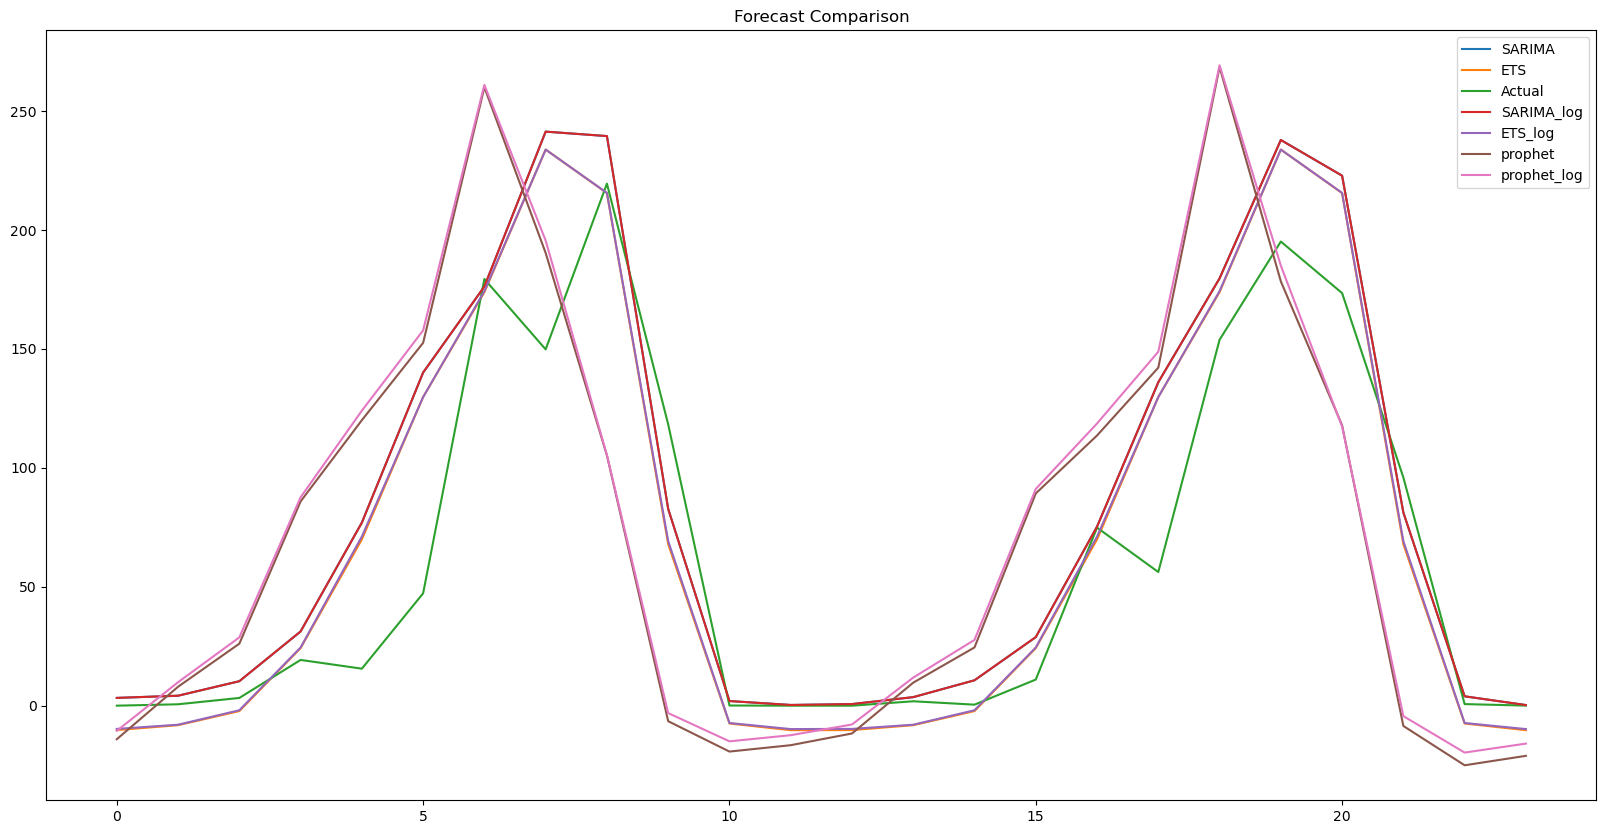

In [103]:
df[['SARIMA', 'ETS', 'Actual', 'SARIMA_log', 'ETS_log', 'prophet', 'prophet_log']].plot(kind = 'line', figsize=(20, 10),
    title='Forecast Comparison')